In [1]:
import pandas as pd
import warnings as ws
ws.filterwarnings('ignore')

In [2]:
dataset =pd.read_csv("Preplacement.csv")

In [3]:
dataset.isna().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [4]:
import seaborn as sb

<Axes: xlabel='ssc_p', ylabel='Density'>

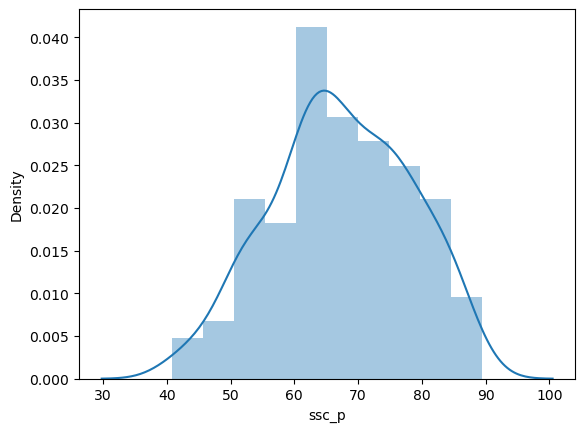

In [5]:
sb.distplot(dataset["ssc_p"])

In [10]:
#Method for plot Prabability Density function
#pdf = probability density function
#cdf = Cumlative density function
#dataset - Column data
#startrange - start point to plot 
#endrange - end point to plot
#from scipy.stats import norm - use as 1. Calculate Probability Density Function (PDF), Calculate Cumulative Distribution Function (CDF), Find the Z-score (Percent Point Function - PPF)
#import seaborn as sns - plot high level data with attraction

def get_pdf_probability(dataset, startrange, endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns

    #kde - Kernel Density Estimate (KDE)
    #sns.distplot(dataset) - Plots the distribution of the data. By default, it shows a histogram and a KDE curve.
    #kde=True - Adds a Kernel Density Estimate (KDE) curve, which is a smooth estimate of the data distribution.
    #kde_kws={'color':'blue'} - Sets the KDE curve color to blue
    #color='green'- Sets the histogram bars to green.
    #pyplot.axvline() - Draws a vertical line on the plot.    
    
    ax = sns.distplot(dataset, kde=True,kde_kws={'color':'blue'}, color='Green')
    pyplot.axvline(startrange, color='Red')
    pyplot.axvline(endrange,color ='Red')
    
    #Generate a sample
    sample = dataset
    
    #calculate parameters of mean and standard deviation
    sample_mean= sample.mean()
    sample_std= sample.std()
    print("Mean=%.3f, Standard Deviation=%.3f" %(sample_mean, sample_std))
    
    #define the distribution
    # norm- The normal (Gaussian) distribution from scipy.stats.
    # norm(sample_mean, sample_std) - To create a normal distribution using your own mean and standard deviation.
    dist =norm(sample_mean, sample_std)
    
    
    #sample probabilities for a range of outcomes
    # Add all range value between start and end range and save in value list and finally get in values
    # Find all values proability density and finally get in probabilities
    values =[value for value in range(startrange, endrange)]
    probabilities =[dist.pdf(value) for value in values]
    prob =  sum(probabilities)
    print("The area between range ({},{}):{}".format(startrange, endrange, sum(probabilities)))
    return prob

Mean=67.303, Standard Deviation=10.827
The area between range (50,150):0.950005321505492


np.float64(0.950005321505492)

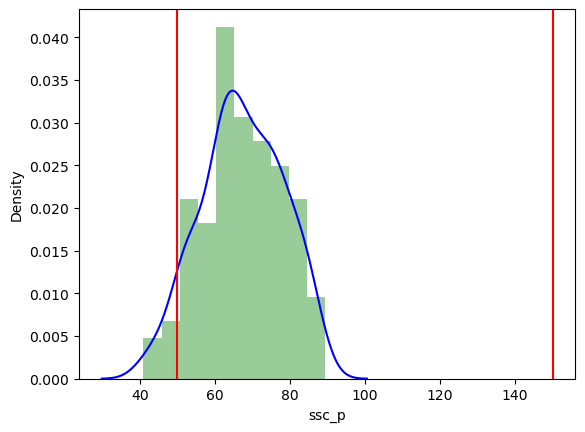

In [16]:
pdfs = get_pdf_probability(dataset["ssc_p"], 50, 150)
pdfs

In [31]:
from statsmodels.distributions.empirical_distribution import ECDF
#ecdf - To calculate cumulative density probabilities.
ecdf = ECDF(dataset["ssc_p"])
ecdf(45)

np.float64(0.023255813953488372)

In [19]:
#!pip install statsmodels

In [46]:
def stdNBgragh(dataset):
    import seaborn as sb
    mean= dataset.mean()
    std= dataset.std()

    #Creates a list containing all values in the dataset.
    values = [i for i in dataset]

    #Calculates the Z-score for every value.
    z_score=[((j-mean)/std) for j in values]

    print(z_score)
    #Draws a histogram of the Z-scores.
    #kde=True adds a smooth density curve.
    sb.distplot(z_score, kde = True, kde_kws={'color':'blue'}, color='Green')
    sum(z_score)/len(z_score)


[np.float64(-0.02802157506744731), np.float64(1.1107764385006722), np.float64(-0.21274144750347646), np.float64(-1.0439808734656075), np.float64(1.7083452258312264), np.float64(-1.136340809683622), np.float64(-1.9675802356457532), np.float64(1.3573774682027713), np.float64(0.5261380422406401), np.float64(-0.8592610010295785), np.float64(-0.8592610010295785), np.float64(0.21211425909939005), np.float64(-1.8752202994277387), np.float64(0.8955777871126984), np.float64(-0.48982125615752015), np.float64(-0.21274144750347646), np.float64(-0.3974613199395056), np.float64(-1.136340809683622), np.float64(-0.3974613199395056), np.float64(-0.6745411285935493), np.float64(-0.48982125615752015), np.float64(1.0802976595487275), np.float64(0.2305862463429932), np.float64(0.9325217615999047), np.float64(0.8493978190036912), np.float64(-1.3598518553312176), np.float64(0.341418169804611), np.float64(-0.3974613199395056), np.float64(0.8734114024203754), np.float64(-0.48982125615752015), np.float64(-0.305

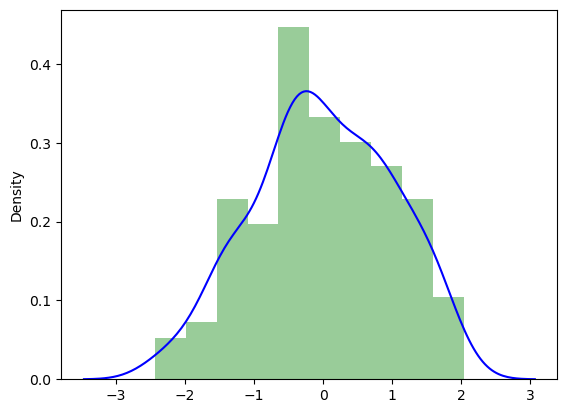

In [47]:
stdNBgragh(dataset["ssc_p"])